# GloGEM vs GloGEMflow: Full Alpine domain

Total volume timeseries for all Central European glaciers (RGI region 11),
comparing the dh/dt parametrisation against the SIA flowline model across four SSPs.

| Model | Geometry approach | Style |
|-------|-------------------|-------|
| **GloGEMflow** | SIA flowline dynamics (Zekollari et al. 2019) | solid |
| **GloGEM dhdt** | dh/dt parametrisation (Huss et al. 2010) | dashed |

Flow model: GCM-mean of BCC-CSM2-MR, CAMS-CSM1-0, CESM2.  
dhdt: BCC-CSM2-MR only.  
ssp585 flow missing ~6 % of glaciers (batch02).

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

rcParams['font.family']       = 'sans-serif'
rcParams['font.sans-serif']   = ['Liberation Sans', 'Arial', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['axes.spines.top']    = False
rcParams['axes.spines.right']  = False

In [31]:
# ── Paths ────────────────────────────────────────────────────────────────────
_BASE = '/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
_SUB  = 'monthly/CentralEurope/files/files_original'

DIR_DHDT = f'{_BASE}/alps_dhdt'
DIR_FLOW = f'{_BASE}/alps_flow'

SUFFIX_DHDT = '_r1'
SUFFIX_FLOW = '_r1'

# ── Batch-parallel flow output ────────────────────────────────────────────────
N_FLOW_BATCHES = 16
BATCH_PREFIX   = 'alps_batch'

# ── GCMs ──────────────────────────────────────────────────────────────────────
DHDT_GCM  = 'BCC-CSM2-MR'                              # only GCM available for dhdt
FLOW_GCMS = ['BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2']   # averaged for flow

# ── SSPs and styling ──────────────────────────────────────────────────────────
SSPS       = ['ssp126', 'ssp245', 'ssp585']
SSP_LABELS = {'ssp126': 'SSP1-2.6', 'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}
SSP_COLORS = {'ssp126': '#5492CD', 'ssp245': '#F6B334', 'ssp585': '#DC1C13'}
LW = 2.0

# ── Time axis ─────────────────────────────────────────────────────────────────
TRAN0   = 1940
N_YEARS = 161          # 1940–2100 inclusive
years   = np.arange(TRAN0, TRAN0 + N_YEARS)
I_2020  = 2020 - TRAN0

In [32]:
import re
_num_re = re.compile(r'[+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?')

def _read_dat(path, row_max=None):
    """Read one .dat file; return column-summed array or None if missing."""
    try:
        with open(path) as fh:
            header = fh.readline()
            ncols  = len(header.split()) - 1
            total  = np.zeros(ncols)
            for line in fh:
                # Strip IDL overflow asterisks, then extract all numeric tokens.
                # This handles: '*' padding, merged adjacent values (no space),
                # and rows shorter than ncols (missing tail → 0).
                nums = _num_re.findall(line.replace('*', ''))
                if len(nums) < 2:
                    continue
                vals = np.zeros(ncols)
                for j, n in enumerate(nums[1:ncols + 1]):  # nums[0] = glacier ID
                    vals[j] = float(n)
                if row_max is not None and np.max(vals) > row_max:
                    continue  # skip blown-up glacier row
                total += vals
    except FileNotFoundError:
        return None
    return total


def load_total(rundir, suffix, var, ssp, gcm=None, row_max=None):
    """Sum `var` across all glaciers for one (rundir, gcm, ssp) combination."""
    if gcm is None:
        gcm = DHDT_GCM
    base = f'{rundir}/{_SUB}/{gcm}/{ssp}/centraleurope_{var}'

    if rundir == DIR_FLOW and N_FLOW_BATCHES > 0:
        total, found = None, 0
        for i in range(1, N_FLOW_BATCHES + 1):
            path = f'{base}_r1_{BATCH_PREFIX}{i:02d}.dat'
            arr  = _read_dat(path, row_max=row_max)
            if arr is not None:
                total = arr if total is None else total + arr
                found += 1
        if total is None:
            print(f'[missing] all batches: {gcm}/{var}/{ssp}')
        elif found < N_FLOW_BATCHES:
            print(f'[partial {found}/{N_FLOW_BATCHES}] {gcm}/{var}/{ssp}')
        return total

    path = f'{base}{suffix}.dat'
    result = _read_dat(path, row_max=row_max)
    if result is None:
        print(f'[missing] {path}')
    return result


def load_flow_mean(var, ssp, row_max=None):
    """Return GCM-mean across FLOW_GCMS for the flow run."""
    arrs = [load_total(DIR_FLOW, SUFFIX_FLOW, var, ssp, gcm=g, row_max=row_max) for g in FLOW_GCMS]
    arrs = [a for a in arrs if a is not None]
    return np.mean(arrs, axis=0) if arrs else None

In [33]:
vol_dhdt  = {s: load_total(DIR_DHDT, SUFFIX_DHDT, 'Volume', s, gcm=DHDT_GCM, row_max=50.) for s in SSPS}
vol_flow  = {s: load_flow_mean('Volume', s, row_max=50.) for s in SSPS}
area_dhdt = {s: load_total(DIR_DHDT, SUFFIX_DHDT, 'Area',   s, gcm=DHDT_GCM, row_max=500.) for s in SSPS}
area_flow = {s: load_flow_mean('Area', s, row_max=500.) for s in SSPS}

# Sanity check
for s in SSPS:
    v_d = vol_dhdt[s]
    v_f = vol_flow[s]
    tag = SSP_LABELS[s]
    if v_d is not None:
        print(f'{tag}  dhdt  vol_2020={v_d[I_2020]:.1f} km³   vol_2100={v_d[-1]:.1f} km³')
    if v_f is not None:
        print(f'{tag}  flow  vol_2020={v_f[I_2020]:.1f} km³   vol_2100={v_f[-1]:.1f} km³')

[partial 15/16] BCC-CSM2-MR/Volume/ssp585
[partial 15/16] CAMS-CSM1-0/Volume/ssp585
[partial 15/16] CESM2/Volume/ssp585
[partial 15/16] BCC-CSM2-MR/Area/ssp585
[partial 15/16] CAMS-CSM1-0/Area/ssp585
[partial 15/16] CESM2/Area/ssp585
SSP1-2.6  dhdt  vol_2020=88.8 km³   vol_2100=21.6 km³
SSP1-2.6  flow  vol_2020=180.5 km³   vol_2100=194.2 km³
SSP2-4.5  dhdt  vol_2020=88.3 km³   vol_2100=6.9 km³
SSP2-4.5  flow  vol_2020=153.6 km³   vol_2100=158.2 km³
SSP5-8.5  dhdt  vol_2020=88.9 km³   vol_2100=1.5 km³
SSP5-8.5  flow  vol_2020=143.1 km³   vol_2100=128.7 km³


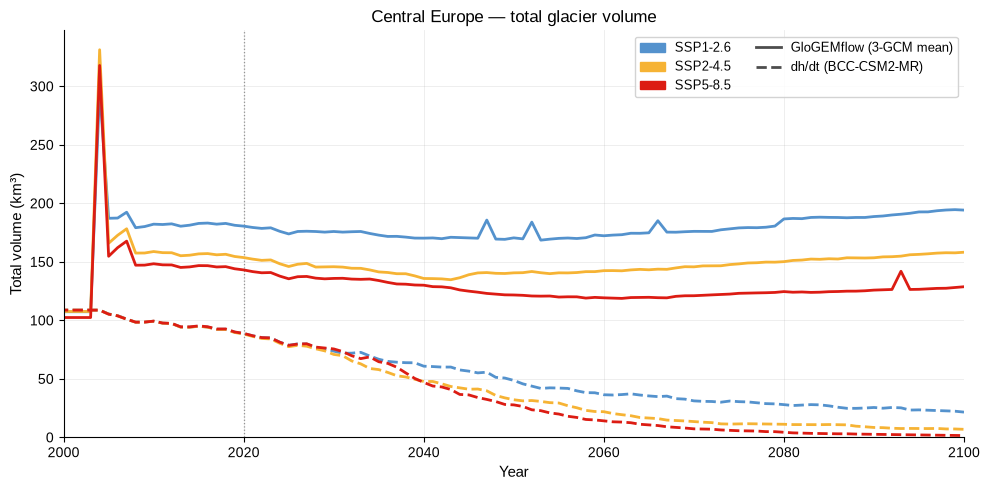

In [34]:
import os
os.makedirs('../figs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))

for ssp in SSPS:
    c = SSP_COLORS[ssp]
    if vol_flow[ssp] is not None:
        ax.plot(years, vol_flow[ssp], ls='-',  lw=LW, color=c)
    if vol_dhdt[ssp] is not None:
        ax.plot(years, vol_dhdt[ssp], ls='--', lw=LW, color=c)

ax.axvline(2020, color='0.55', lw=0.9, ls=':', zorder=0)
ax.set_xlim(2000, 2100)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total volume (km³)', fontsize=11)
ax.set_title('Central Europe — total glacier volume', fontsize=12)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=LW, label='GloGEMflow (3-GCM mean)'),
    Line2D([0], [0], color='0.3', ls='--', lw=LW, label='dh/dt (BCC-CSM2-MR)'),
]
ax.legend(handles=legend_ssp + legend_mdl, ncol=2, fontsize=9,
          loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.25, lw=0.6)

fig.tight_layout()
fig.savefig('../figs/alps_full_volume.pdf', dpi=150, bbox_inches='tight')
plt.show()

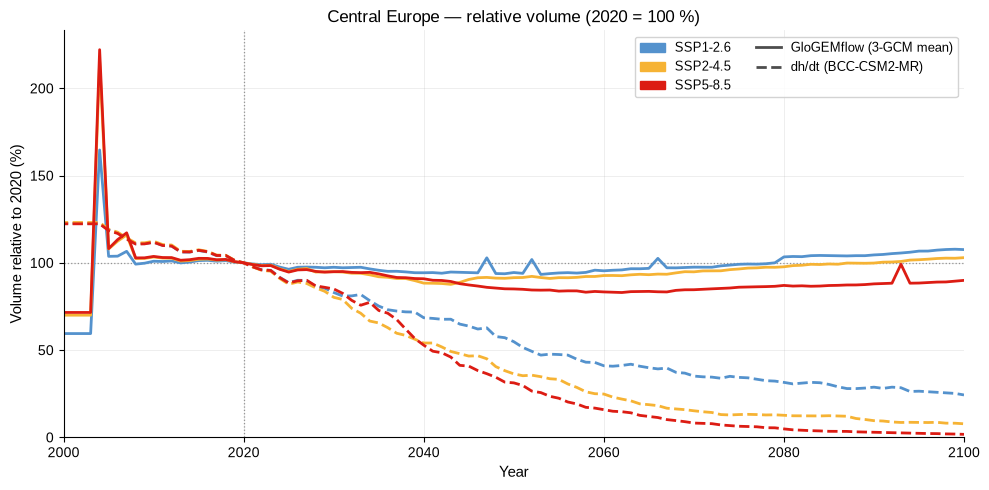

In [35]:
# ── Figure 2: Volume relative to 2020 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for ssp in SSPS:
    c = SSP_COLORS[ssp]
    if vol_flow[ssp] is not None and vol_flow[ssp][I_2020] > 0:
        ref = vol_flow[ssp][I_2020]
        ax.plot(years, vol_flow[ssp] / ref * 100, ls='-',  lw=LW, color=c)
    if vol_dhdt[ssp] is not None and vol_dhdt[ssp][I_2020] > 0:
        ref = vol_dhdt[ssp][I_2020]
        ax.plot(years, vol_dhdt[ssp] / ref * 100, ls='--', lw=LW, color=c)

ax.axhline(100, color='0.55', lw=0.9, ls=':', zorder=0)
ax.axvline(2020, color='0.55', lw=0.9, ls=':', zorder=0)
ax.set_xlim(2000, 2100)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Volume relative to 2020 (%)', fontsize=11)
ax.set_title('Central Europe — relative volume (2020 = 100 %)', fontsize=12)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=LW, label='GloGEMflow (3-GCM mean)'),
    Line2D([0], [0], color='0.3', ls='--', lw=LW, label='dh/dt (BCC-CSM2-MR)'),
]
ax.legend(handles=legend_ssp + legend_mdl, ncol=2, fontsize=9,
          loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.25, lw=0.6)

fig.tight_layout()
fig.savefig('../figs/alps_full_volume_relative.pdf', dpi=150, bbox_inches='tight')
plt.show()

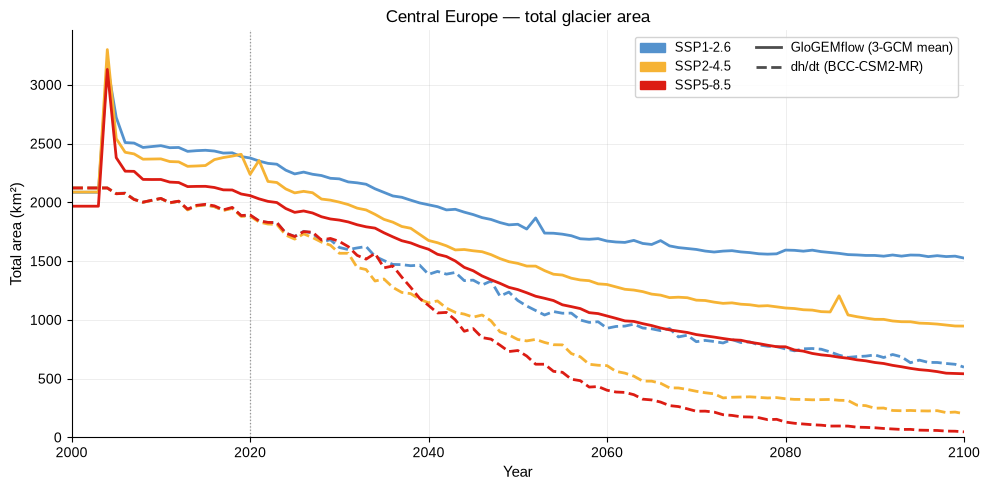

In [36]:
# ── Figure 3: Total area ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for ssp in SSPS:
    c = SSP_COLORS[ssp]
    if area_flow[ssp] is not None:
        ax.plot(years, area_flow[ssp], ls='-',  lw=LW, color=c)
    if area_dhdt[ssp] is not None:
        ax.plot(years, area_dhdt[ssp], ls='--', lw=LW, color=c)

ax.axvline(2020, color='0.55', lw=0.9, ls=':', zorder=0)
ax.set_xlim(2000, 2100)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total area (km²)', fontsize=11)
ax.set_title('Central Europe — total glacier area', fontsize=12)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=LW, label='GloGEMflow (3-GCM mean)'),
    Line2D([0], [0], color='0.3', ls='--', lw=LW, label='dh/dt (BCC-CSM2-MR)'),
]
ax.legend(handles=legend_ssp + legend_mdl, ncol=2, fontsize=9,
          loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.25, lw=0.6)

fig.tight_layout()
fig.savefig('../figs/alps_full_area.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Summary table ─────────────────────────────────────────────────────────────
# Volume and area remaining in 2100 relative to 2020.
I_2100 = 2100 - TRAN0

header = f"{'SSP':<12}  {'V2020_d':>8}  {'V2100_d':>8}  {'Vloss_d':>8}  "
header +=           f"{'V2020_f':>8}  {'V2100_f':>8}  {'Vloss_f':>8}"
print(header)
print('-' * len(header))

for ssp in SSPS:
    lbl = SSP_LABELS[ssp]
    vd0 = vol_dhdt[ssp][I_2020] if vol_dhdt[ssp] is not None else float('nan')
    vd1 = vol_dhdt[ssp][I_2100] if vol_dhdt[ssp] is not None else float('nan')
    vf0 = vol_flow[ssp][I_2020]  if vol_flow[ssp]  is not None else float('nan')
    vf1 = vol_flow[ssp][I_2100]  if vol_flow[ssp]  is not None else float('nan')
    loss_d = (1 - vd1 / vd0) * 100 if vd0 > 0 else float('nan')
    loss_f = (1 - vf1 / vf0) * 100 if vf0 > 0 else float('nan')
    print(f'{lbl:<12}  {vd0:>8.1f}  {vd1:>8.1f}  {loss_d:>7.1f}%  '
          f'{vf0:>8.1f}  {vf1:>8.1f}  {loss_f:>7.1f}%')

print()
print('All values in km³.  V2020: volume in 2020.  Vloss: % volume loss 2020→2100.')

SSP            V2020_d   V2100_d   Vloss_d   V2020_f   V2100_f   Vloss_f
------------------------------------------------------------------------
SSP1-2.6          88.8      21.6     75.7%     410.2     436.3     -6.4%
SSP2-4.5          88.3       6.9     92.2%     367.8     392.4     -6.7%
SSP5-8.5          88.9       1.5     98.3%     356.6     367.8     -3.1%

All values in km³.  V2020: volume in 2020.  Vloss: % volume loss 2020→2100.
